# Análise de Vendas de Bicicletas

Projeto de análise exploratória do dataset `uncleaned_bike_sales_data.xlsx`.

**Estrutura:**
1. Limpeza e tratamento (executada em `limpeza.py`, gera `cleaned_bike_sales_data.csv`)
2. Análise exploratória
3. Conclusões

## 1. Setup

Carregamento do dataset já tratado. Para regerar o CSV, executar `python limpeza.py`.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.titlepad': 40,
    'axes.labelsize': 14,
    'axes.labelpad': 40,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
})

df_analise = pd.read_csv('cleaned_bike_sales_data.csv', sep=';', parse_dates=['data'])
df_analise['receita'] = df_analise['preco_unitario'] * df_analise['quantidade']
df_analise.head()

,pedido_venda,data,idade_cliente,faixa_etaria,genero_cliente,pais,estado,categoria_produto,subcategoria,quantidade,custo_unitario,preco_unitario,lucro,receita
0,261695,2021-12-01,39,Adults (35-64),Feminino,United States,California,Bikes,Mountain Bikes,4,1252.0,2295.0,4172.0,9180.0
1,261697,2021-12-02,37,Adults (35-64),Masculino,United States,California,Bikes,Mountain Bikes,2,420.0,769.0,698.0,1538.0
2,261698,2021-12-02,31,Young Adults (25-34),Feminino,Australia,New South Wales,Bikes,Mountain Bikes,1,420.0,769.0,349.0,769.0
3,261699,2021-12-03,37,Adults (35-64),Feminino,United States,California,Bikes,Mountain Bikes,2,0.0,2295.0,2086.0,4590.0
4,261700,2021-12-03,24,Youth (<25),Feminino,United Kingdom,England,Bikes,Mountain Bikes,1,1252.0,2295.0,1043.0,2295.0


## 2. Análise exploratória

_5 estados mais lucrativos (dez/2021)_

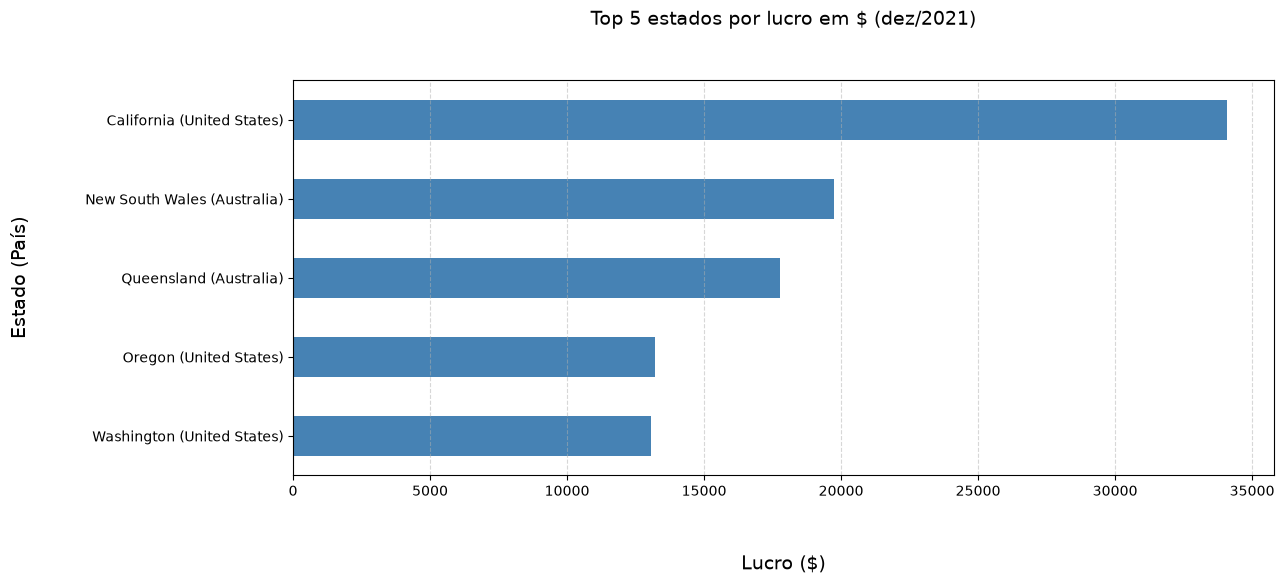

In [2]:

top_state_profit = (
    df_analise.groupby(['estado', 'pais'])[['lucro']].sum()
    .sort_values(by='lucro', ascending=False)
    .head()
)
top_state_profit.index = [f'{estado} ({pais})' for estado, pais in top_state_profit.index]
top_state_profit.style.format('${:,.2f}')

ax = top_state_profit['lucro'].plot(
    kind='barh',
    title='Top 5 estados por lucro em $ (dez/2021)',
    ylabel='Estado (País)',
    xlabel='Lucro ($)',
    figsize=(13, 6),
    color='steelblue',
)

ax.grid(axis='x', linestyle='--', alpha=0.5)

plt.gca().invert_yaxis() 
plt.tight_layout()
plt.show()

_5 países mais lucrativos (dez/2021)_

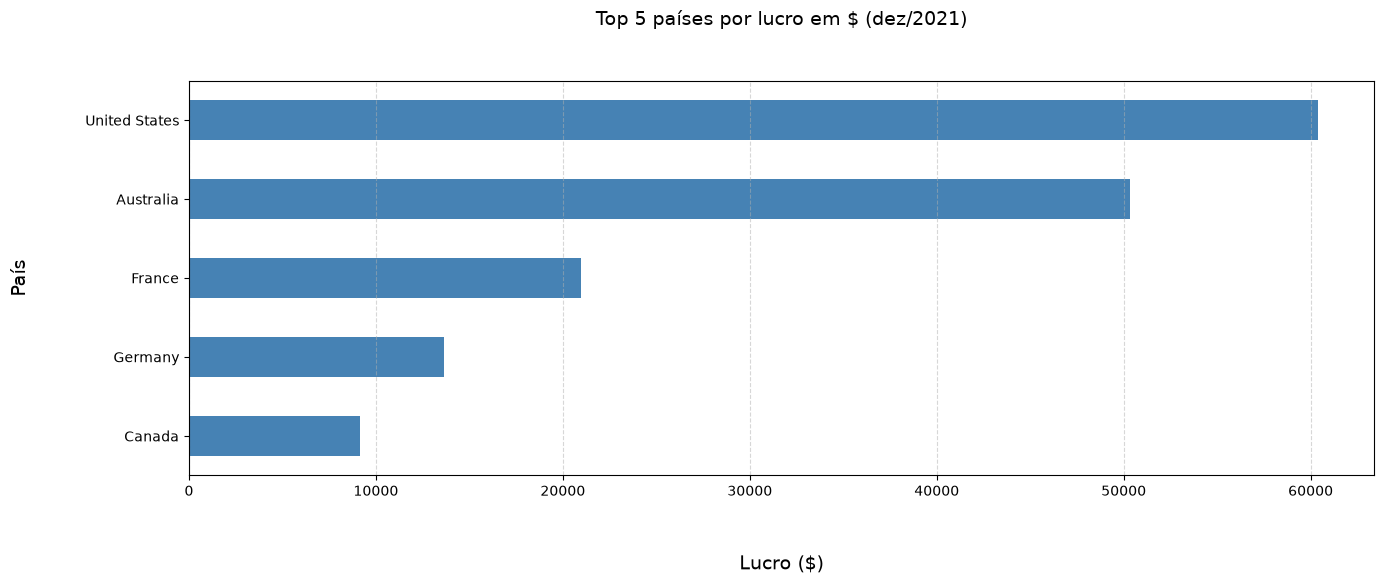

In [3]:
top_country_profit = (
    df_analise.groupby('pais')[['lucro']].sum()   # note o [['lucro']]
    .sort_values(by='lucro', ascending=False)
    .head()
)
top_country_profit.style.format('${:,.2f}')

ax = top_country_profit['lucro'].plot(
    kind='barh',
    title='Top 5 países por lucro em $ (dez/2021)',
    ylabel='País',
    xlabel='Lucro ($)',
    figsize=(14, 6),
    color='steelblue',
)

ax.grid(axis='x', linestyle='--', alpha=0.5)


plt.gca().invert_yaxis() 
plt.tight_layout()
plt.show()

_Ticket médio de lucro por país (dez/2021)_

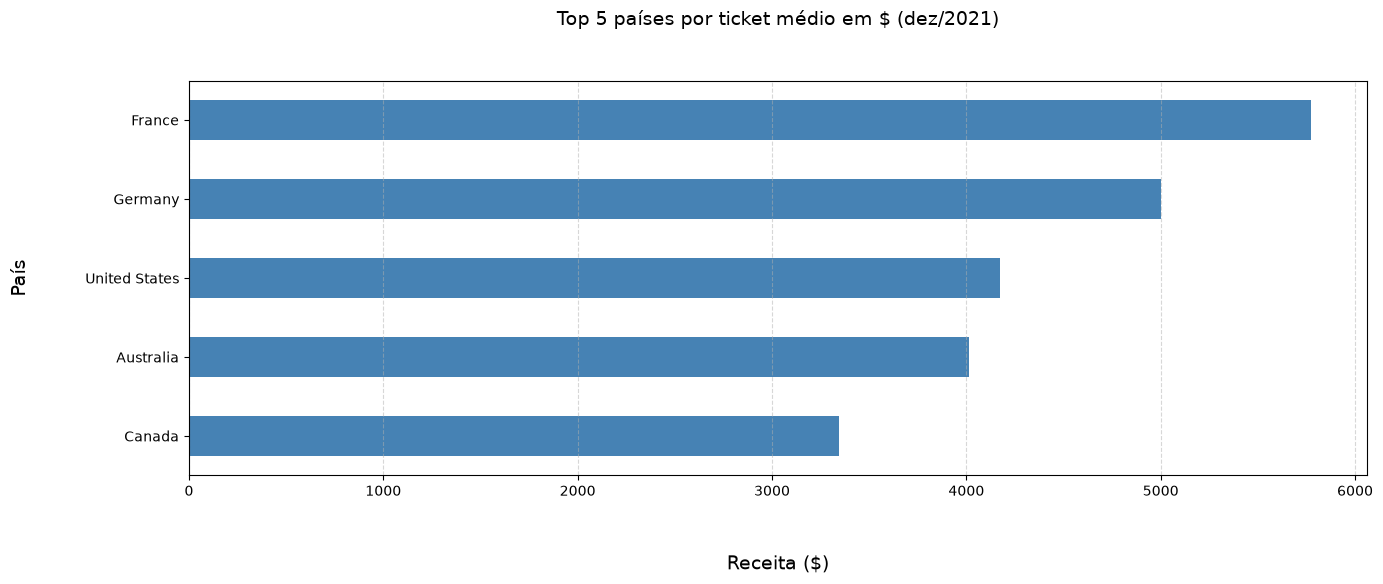

In [4]:

top_country_aov = df_analise.groupby('pais')[['receita']].mean().sort_values(by='receita',ascending=False).head()
top_country_aov.style.format('${:,.2f}')

ax = top_country_aov['receita'].plot(
    kind='barh',
    title="Top 5 países por ticket médio em $ (dez/2021)",
    ylabel='País',
    xlabel='Receita ($)',
    figsize=(14, 6),
    color='steelblue',
)

ax.grid(axis='x', linestyle='--', alpha=0.5)


plt.gca().invert_yaxis() 
plt.tight_layout()
plt.show()


_Ranking de compra por faixa etária (dez/2021)_

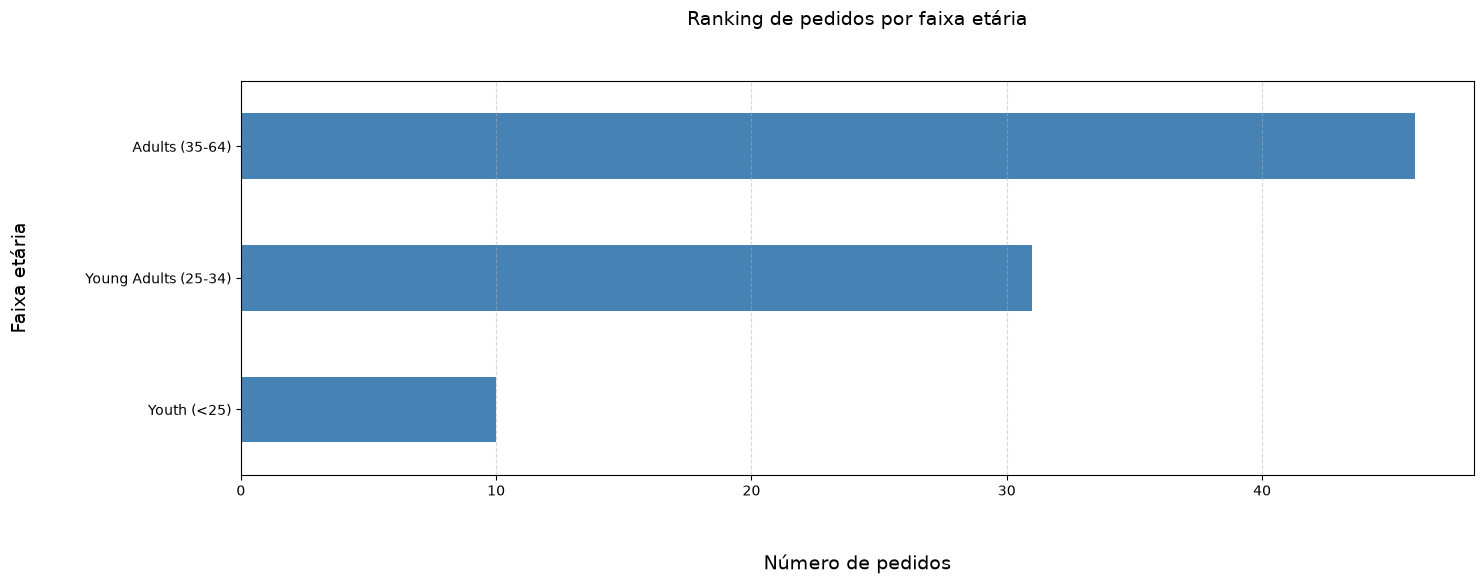

,pedido_venda
faixa_etaria,
Adults (35-64),46
Young Adults (25-34),31
Youth (<25),10


In [5]:
age_group_rank = df_analise.groupby(['faixa_etaria'])[['pedido_venda']].count()

ax = age_group_rank['pedido_venda'].plot(
    kind='barh',
    title="Ranking de pedidos por faixa etária",
    ylabel='Faixa etária',
    xlabel='Número de pedidos',
    figsize=(15, 6),
    color='steelblue',
)

ax.grid(axis='x', linestyle='--', alpha=0.5)


plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
age_group_rank

_Ranking de pedidos por gênero do cliente (dez/2021)_

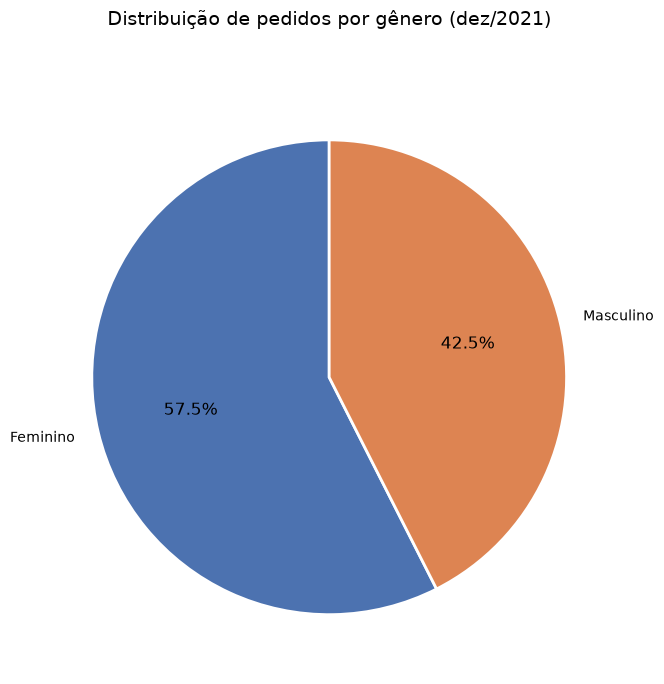

In [6]:
order_gender_customer = df_analise.groupby(['genero_cliente'])[['pedido_venda']].count()

order_gender_customer['pedido_venda'].plot(
    kind='pie',
    title='Distribuição de pedidos por gênero (dez/2021)',
    figsize=(7, 7),
    autopct='%.1f%%',
    startangle=90,
    colors=['#4C72B0', '#DD8452'],
    ylabel='',
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
)

plt.tight_layout()
plt.show()



_Ticket médio por gênero_

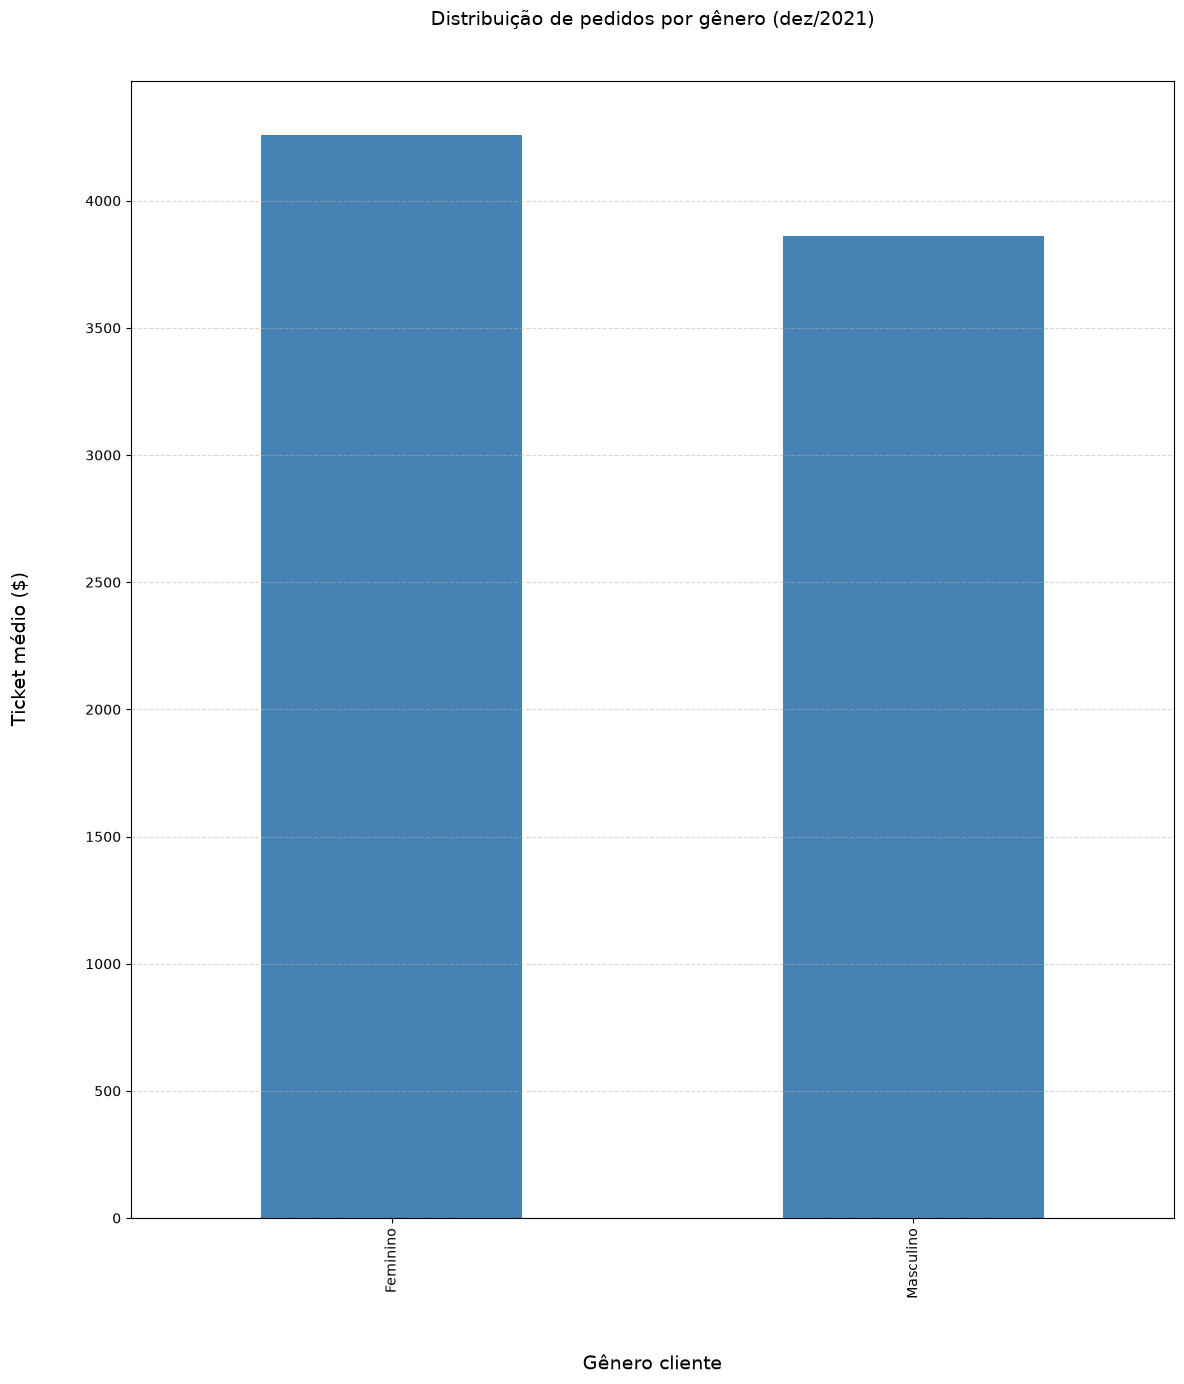

,receita
genero_cliente,
Feminino,"$4,259.46"
Masculino,"$3,861.16"


In [7]:

top_aov_gender = df_analise.groupby('genero_cliente')[['receita']].mean()

ax = top_aov_gender['receita'].plot(
    kind='bar',
    ylabel='Ticket médio ($)',
    xlabel='Gênero cliente',
    title='Distribuição de pedidos por gênero (dez/2021)',
    figsize=(12, 14),
    color='steelblue',
)

ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

top_aov_gender.style.format('${:,.2f}')

_Evolução do lucro ao longo dos dias (dez/2021)_

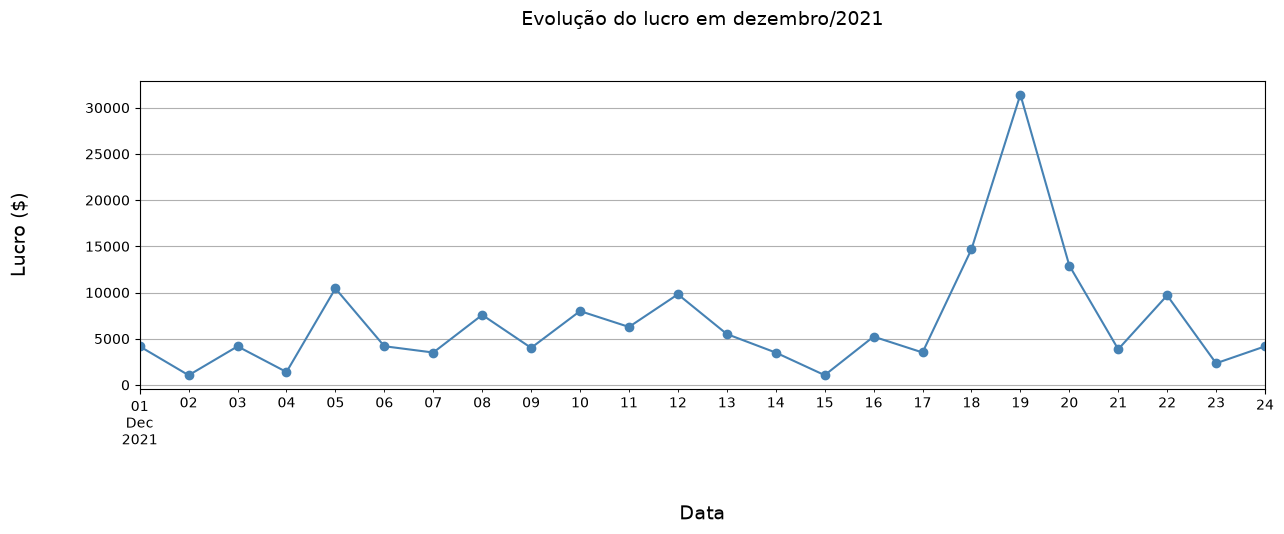

,Lucro
data,
2021-12-01 00:00:00,"$ 4.172,00"
2021-12-02 00:00:00,"$ 1.047,00"
2021-12-03 00:00:00,"$ 4.172,00"
2021-12-04 00:00:00,"$ 1.396,00"
2021-12-05 00:00:00,"$ 10.441,00"
2021-12-06 00:00:00,"$ 4.187,00"
2021-12-07 00:00:00,"$ 3.504,00"
2021-12-08 00:00:00,"$ 7.575,00"
2021-12-09 00:00:00,"$ 4.008,00"


In [8]:
# display(df_analise)

day_profit = df_analise.groupby('data')['lucro'].sum()

ax = day_profit.plot(
    kind='line',
    title='Evolução do lucro em dezembro/2021',
    figsize=(13, 5.5),
    xlabel='Data',
    ylabel='Lucro ($)',
    color='steelblue',
    marker='o',
    grid=True,
)


plt.tight_layout()
plt.show()

display(
    day_profit
    .to_frame(name='Lucro')
    .style.format({
        'Lucro': lambda x: f'$ {x:,.2f}'.replace(',', 'X').replace('.', ',').replace('X', '.')
    })
)


## 3. Conclusões

_Principais insights encontrados._

1. Analisando os estados mais lucrativos, 3 deles são dos Estados Unidos (California, Oregon e Washington) e 2 da Austrália (New South Wales e Queensland). Isso já sugere os EUA como país líder em lucro, o que se confirma ao reagregar por país: EUA na frente, seguidos de Austrália, França, Alemanha e Canadá, sendo esses 3 últimos com uma grande disparidade em relação aos dois primeiros. Um ponto interessante é que, dentre esses 5 países, a Austrália é a que detém a menor população (cerca de 27,2 milhões de pessoas), bem menor se comparada com os Estados Unidos ou até mesmo com a Alemanha. Vale reforçar um aprendizado sobre **granularidade** que ficou claro aqui: mesmo quando o ranking por estado aponta para o mesmo líder, o top-N de estados não permite deduzir a ordem nem os totais no nível de país. A Austrália, por exemplo, ficou próxima dos EUA no total (~10k de diferença), enquanto França, Alemanha e Canadá só aparecem ao reagregar. Sempre que mudar a granularidade (estado para país, dia para mês, produto para categoria), é preciso reagregar os dados do zero, nunca deduzir a partir do top-N de outra granularidade.

2. Olhando o ticket médio por país, o ranking se inverte em relação ao lucro total: França ($5.771,88) e Alemanha ($5.001,67) lideram, seguidas por EUA ($4.171,53), Austrália ($4.015,93) e Canadá ($3.346,67). Ou seja, França e Alemanha vendem menos em volume, mas cada pedido tem valor mais alto, ao contrário dos EUA e da Austrália, que ganham no volume.

3. Olhando para o ranking de pedidos por faixa etária, adultos lideram as vendas com cerca de 53% do total, seguidos de jovens adultos com aproximadamente 36% e jovens com apenas 11%. Esses números surpreendem: jovens adultos superando a categoria mais jovem pode indicar uma anomalia, visto que o uso de bicicletas pela categoria mais jovem (crianças, adolescentes) é mais comum do que entre a faixa de 25-34 anos, e talvez até na categoria de adultos, que engloba a faixa de 35 a 64 anos, considerando que o público-alvo desse produto seriam crianças e aposentados. Por outro lado, a alta procura pela parte de adultos/idosos pode se justificar pelo tipo de produto, visto que o dataset contempla bicicletas de estrada, mountain bikes e acessórios, itens mais direcionados ao público adulto do que a crianças.

4. Olhando para vendas por gênero, a categoria feminino lidera tanto em quantidade de pedidos (57,5% contra 42,5%) quanto em ticket médio, este último com pouca disparidade (aproximadamente 10% acima do masculino).

5. Analisando a série temporal de lucro diário, podemos perceber que na grande parte dos dias o lucro fica abaixo de $ 10.000,00, batendo essa meta em apenas 4 dias. Além disso, os lucros dos dias 18 e 19 tiveram um aumento anormal, aproximadamente 46,79% e 214% a mais do que a meta, respectivamente, o que pode ser justificado por uma estratégia de marketing bem-sucedida. A questão é que esse padrão não se manteve. Logo nos dias 20 e 21 se seguiram duas quedas bruscas no lucro. No dia 20 ainda conseguiu se manter acima da meta, mas por apenas cerca de 29%, e no dia 21 ficou 61% abaixo da meta. Com base no gráfico, podemos concluir que o lucro tem variado bastante durante os dias, ficando muitas vezes abaixo da meta.